In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [2]:
WIDTH = 9.0#!6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# Solver and simulation parameters
# M_vector = [4, 5, 6, 7, 8, 9]
M_vector = [4, 5]#!, 6, 8]
closure_vec = ["Gram", "ExtGram", "Grad"] # Grad for M=5 (Kn=1.0 and -> infty) diverged -> negative density
Knudsen = [0.1, 1.0, 10.0]
source_vec = ["relaxation_source", "relaxation_source", "zero_source"]
T_end = 0.3
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# BGK
N = 1_000 # BGK
base_tree_level_bgk = 8
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

In [4]:
# Semi-analytical solution -> Collisionless
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T

In [5]:
colors = ['blue', 'orange', 'green', 'red', 'purple']
linestyles = ['--', '-', ':']

In [6]:
M_vector

[4, 5]

/tmp/ipykernel_2615/3204934248.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_2615/3204934248.py:58: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_2615/3204934248.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ign

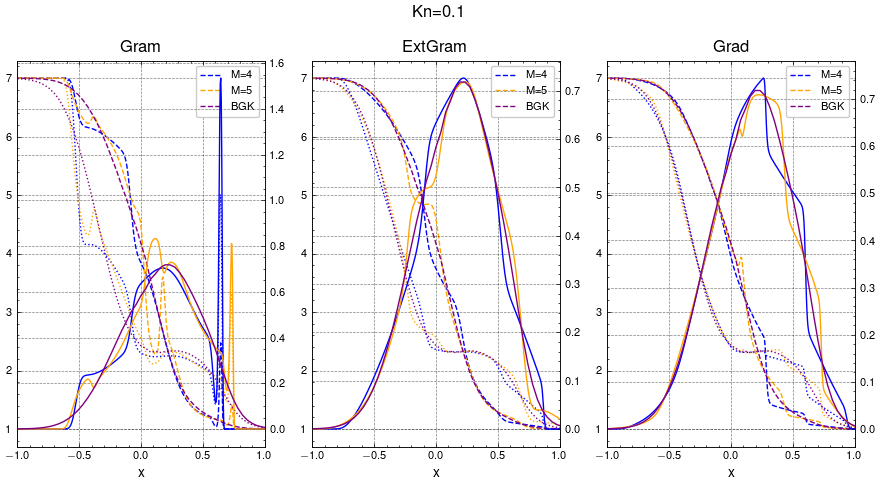

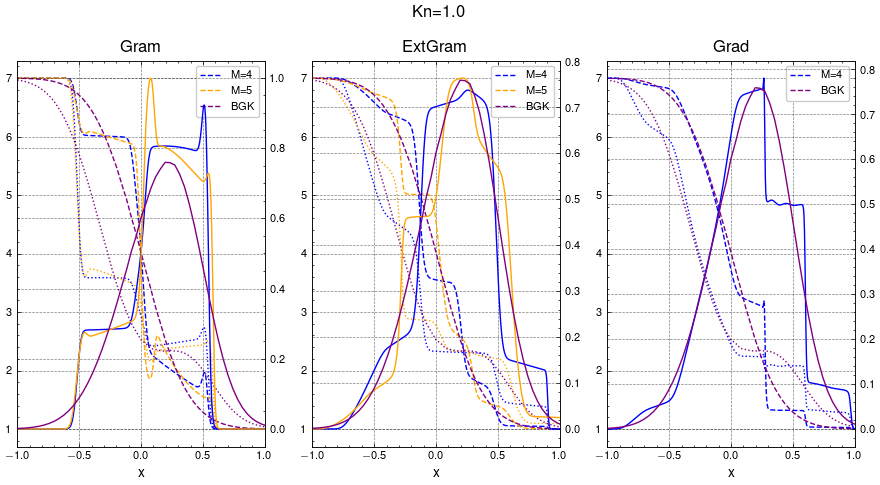

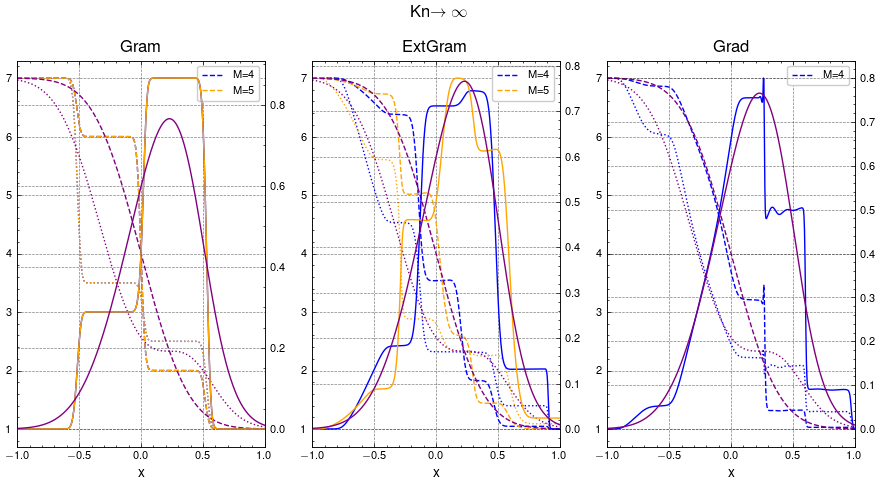

In [7]:
for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    fig, axs = plt.subplots(1, 3)
    twinx = [ax.twinx() for ax in axs]
    for j, closure in enumerate(closure_vec):
        if source == "relaxation_source":
            fig.suptitle(f'Kn={Kn}')
        else:
            fig.suptitle(f'Kn$\\to \\infty$')
        
        [ax.set_xlim(-1, 1) for ax in axs]
        [ax.set_xlabel('x') for ax in axs]
        axs[j].set_title(closure)
        for m, M in enumerate(M_vector):
            if closure == "Grad" and M==5 and Kn in [1.0, 10.0]:
                continue # diverged
            file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[j].plot(x, rho, color=colors[m], ls=linestyles[0], label=f'M={M}')
            twinx[j].plot(x, v, color=colors[m], ls=linestyles[1])
            axs[j].plot(x, p, color=colors[m], ls=linestyles[2])

        # BGK
        if source == "relaxation_source":
            data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

            x_bgk = data_bgk['x'].to_numpy()

            rho_bgk = data_bgk['rho'].to_numpy()
            axs[j].plot(x_bgk, rho_bgk, color=colors[4], ls=linestyles[0], label='BGK')

            v_bgk = data_bgk['v'].to_numpy()
            twinx[j].plot(x_bgk, v_bgk, color=colors[4], ls=linestyles[1])

            p_bgk = data_bgk['p'].to_numpy()
            theta_bgk = p_bgk / rho_bgk
            axs[j].plot(x_bgk, p_bgk, color=colors[4], ls=linestyles[2])
        else: 
            axs[j].plot(Nx, rho_T, color=colors[4], ls=linestyles[0])
            twinx[j].plot(Nx, v_T, color=colors[4], ls=linestyles[1])
            axs[j].plot(Nx, p_T, color=colors[4], ls=linestyles[2])

        fig.tight_layout()
        fig.show()
        
        [ax.legend() for ax in axs]
        # ax_eig_even.legend()
        # ax_eig_odd.legend()

        fig.tight_layout()
        fig.show()

/tmp/ipykernel_1224/2478038244.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/2478038244.py:60: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/2478038244.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/2478038244.py:60: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/2478038244.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/2478038244.py:60: Us

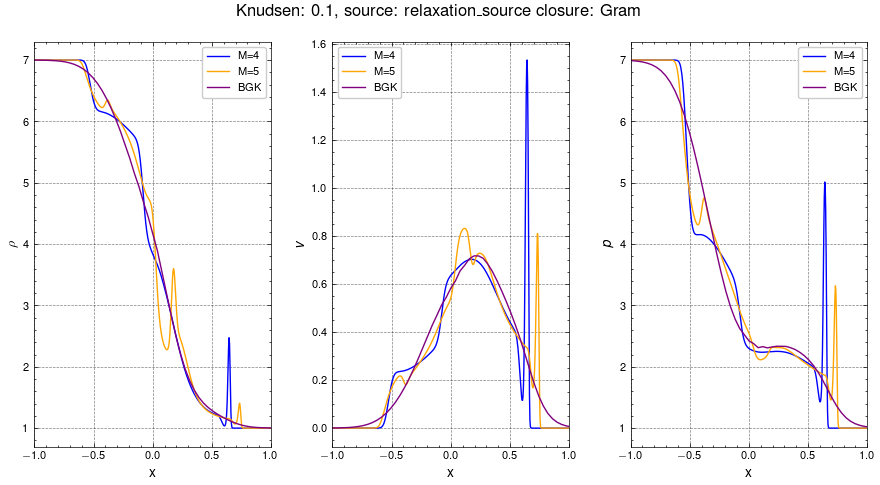

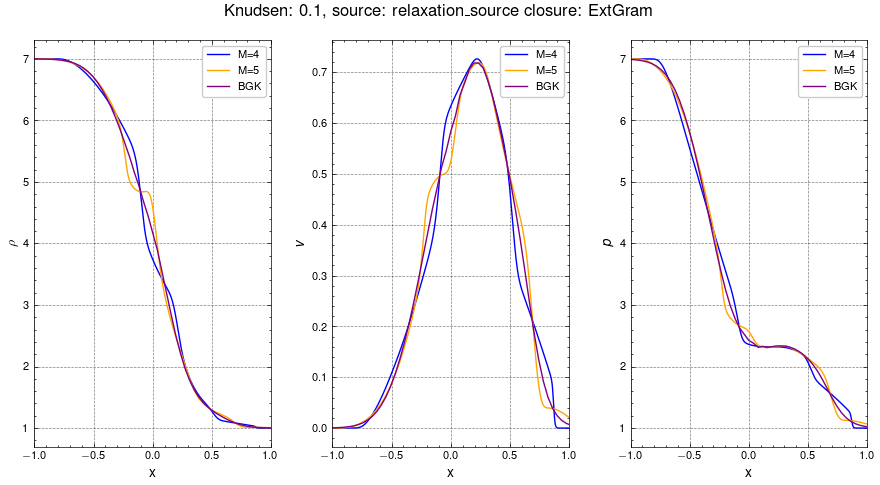

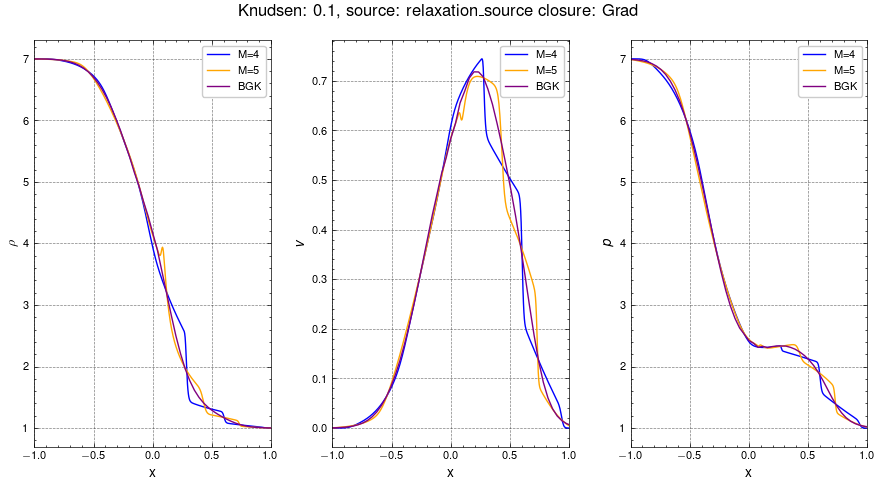

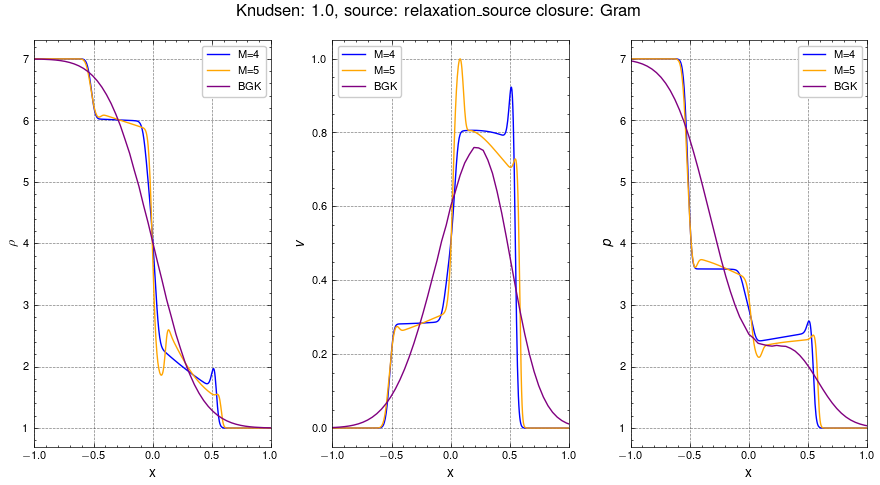

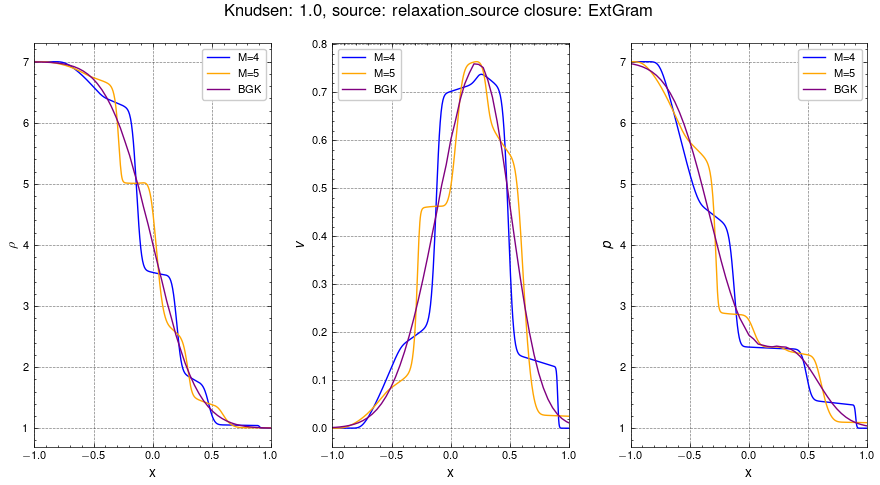

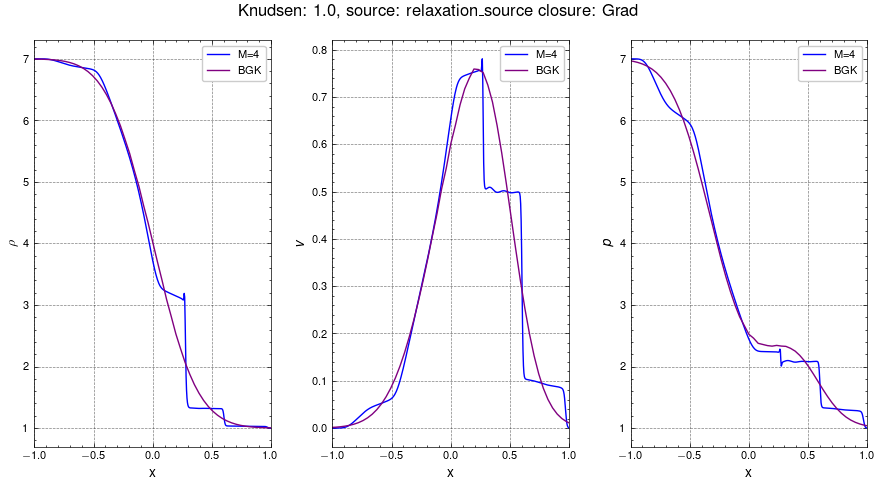

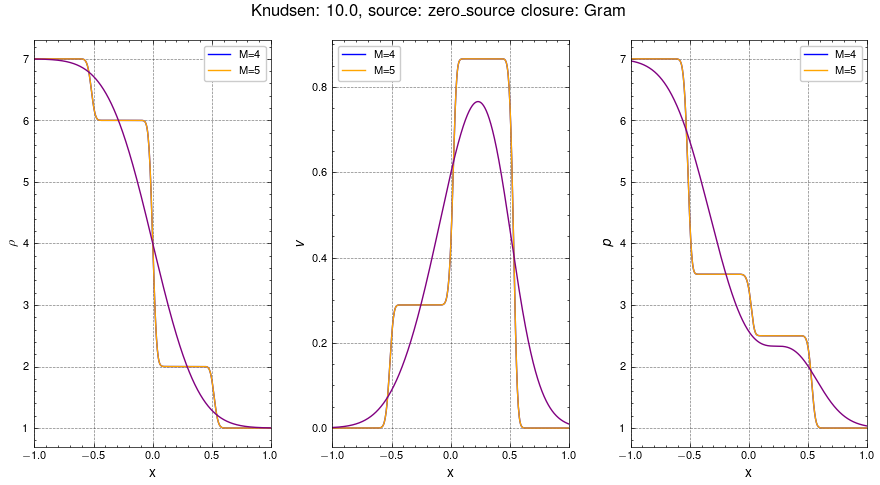

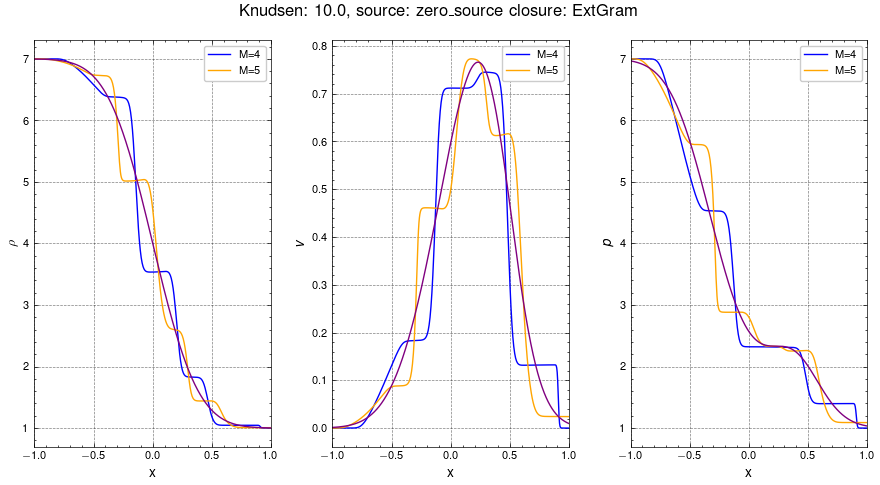

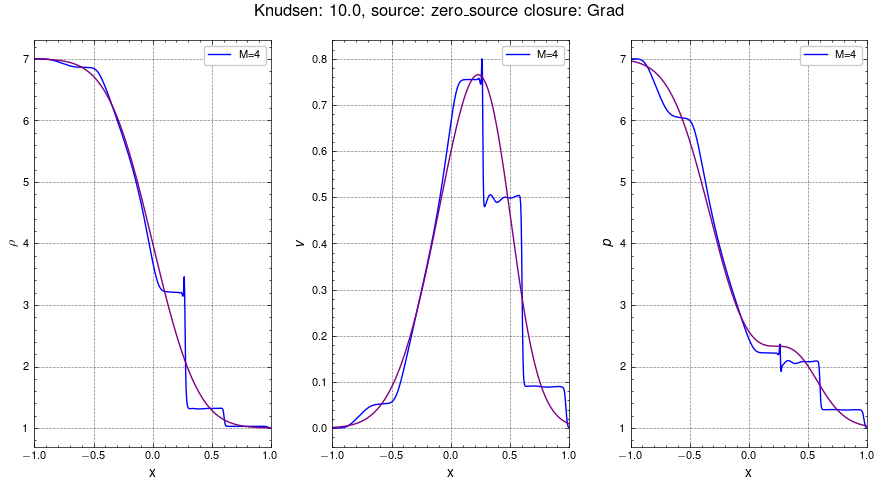

In [38]:
for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    for closure in closure_vec:
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, source: {source} closure: {closure}')

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
        for i, M in enumerate(M_vector):
            if closure == "Grad" and M==5 and Kn in [1.0, 10.0]:
                continue # diverged
            file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # BGK
        if source == "relaxation_source":
            data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

            x_bgk = data_bgk['x'].to_numpy()

            rho_bgk = data_bgk['rho'].to_numpy()
            ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

            v_bgk = data_bgk['v'].to_numpy()
            ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

            p_bgk = data_bgk['p'].to_numpy()
            theta_bgk = p_bgk / rho_bgk
            ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')
        else: 
            ax_rho.plot(Nx, rho_T, color=colors[4])
            ax_v.plot(Nx, v_T, color=colors[4])
            ax_p.plot(Nx, p_T, color=colors[4])

        fig.tight_layout()
        fig.show()
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()
        # ax_eig_even.legend()
        # ax_eig_odd.legend()

        fig.tight_layout()
        fig.show()

/tmp/ipykernel_1224/3837948119.py:104: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/3837948119.py:104: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


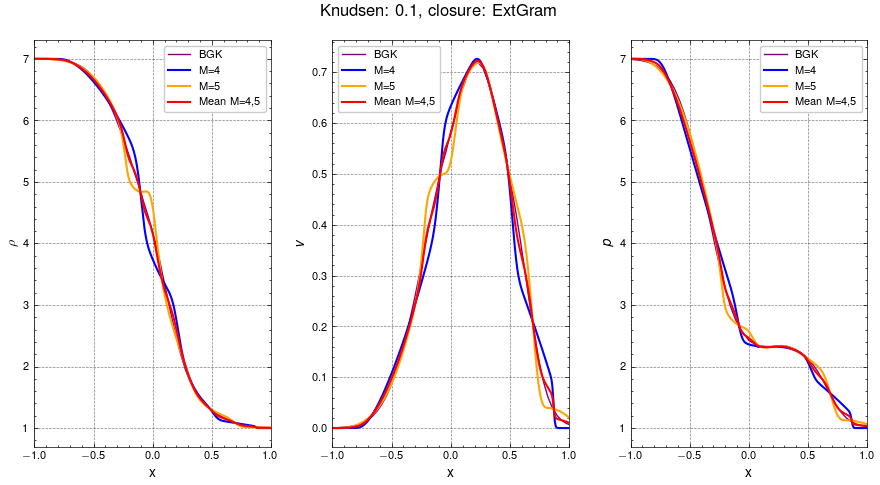

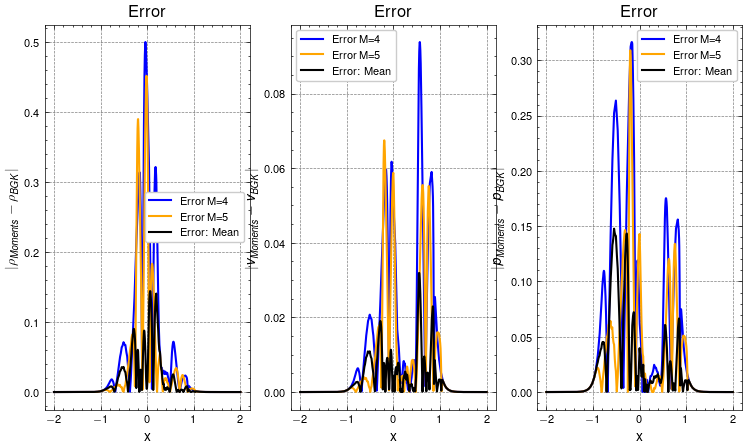

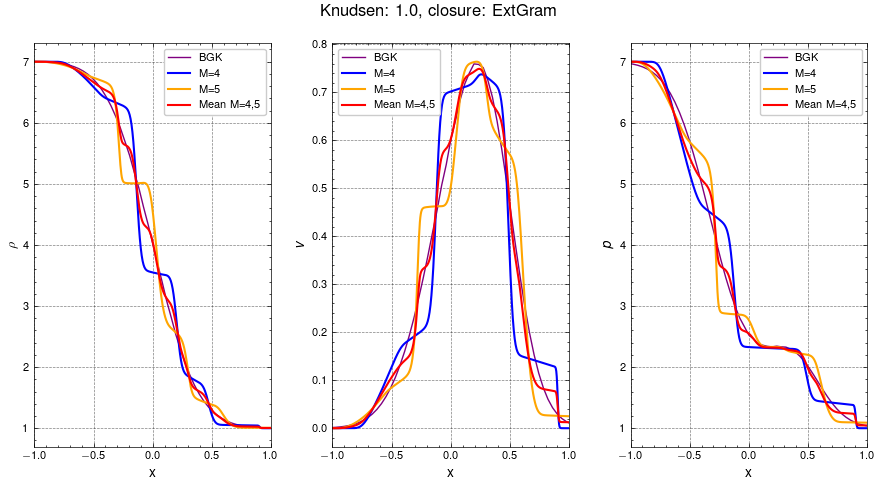

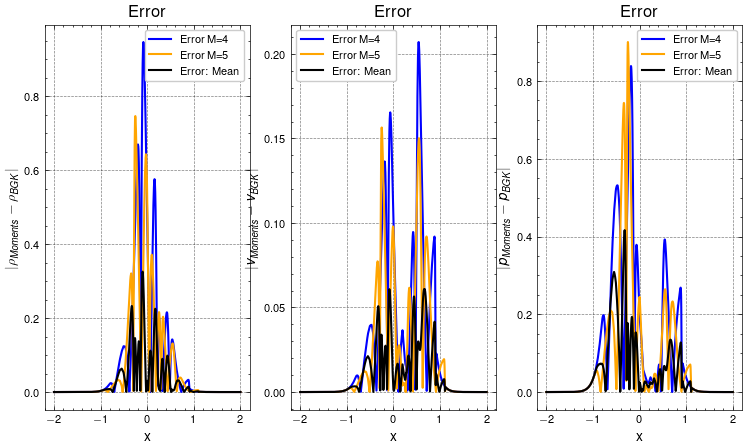

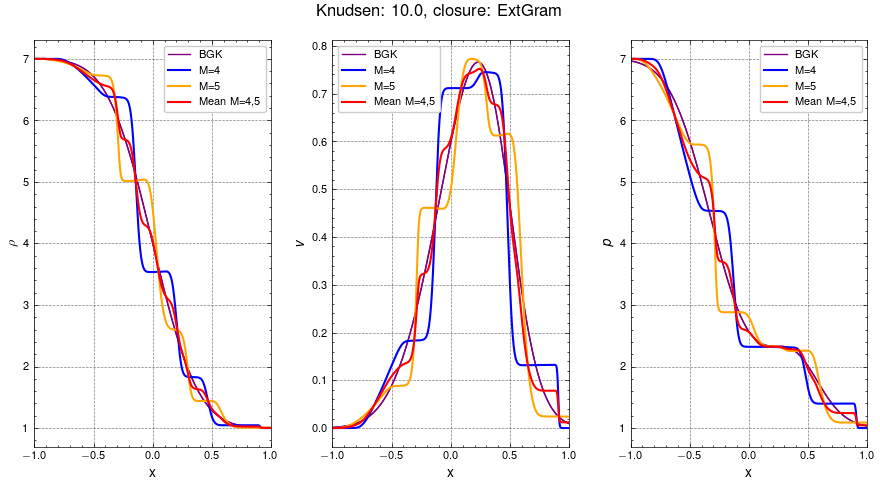

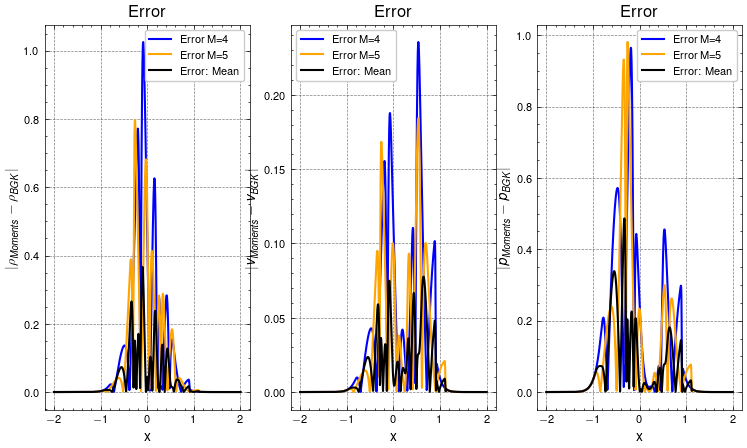

In [46]:
Moments = [4, 5]

for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    for closure in closure_vec:
        if closure != "ExtGram":
            continue # only interested in Extended Gramian here
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
        fig_error, axs_error = plt.subplots(1, 3)

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

        # BGK
        if source == "relaxation_source":
            data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

            x_bgk = data_bgk['x'].to_numpy()
            rho_bgk = data_bgk['rho'].to_numpy()
            v_bgk = data_bgk['v'].to_numpy()
            p_bgk = data_bgk['p'].to_numpy()
            theta_bgk = p_bgk / rho_bgk
        else: 
            x_bgk = Nx
            rho_bgk = rho_T
            v_bgk = v_T
            p_bgk = p_T
            ax_rho.plot(Nx, rho_T, color=colors[4])
            ax_v.plot(Nx, v_T, color=colors[4])
            ax_p.plot(Nx, p_T, color=colors[4])

        ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')
        ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')
        ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')

        rho_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, rho_bgk)
        v_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, v_bgk)
        p_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, p_bgk)

        rho_vector, v_vector, p_vector = [], [], []
        
        for i, M in enumerate(Moments):
            if closure == "Grad" and M==5:
                continue # diverged
            # Moments
            file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            rho_vector.append(rho)
            v = u[:, 1] / rho
            v_vector.append(v)
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            p_vector.append(p)
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

            axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        # Mean of M=4 and M=5
        if closure != "Grad":
            rho_mean = 0.5 * (rho_vector[0] + rho_vector[1])
            v_mean = 0.5 * (v_vector[0] + v_vector[1])
            p_mean = 0.5 * (p_vector[0] + p_vector[1])

            ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()

        if closure != "Grad":
            axs_error[0].set_title('Error')
            axs_error[0].set_xlabel('x')
            axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{BGK}|$')
            axs_error[1].set_title('Error')
            axs_error[1].set_xlabel('x')
            axs_error[1].set_ylabel('$|v_{Moments} - v_{BGK}|$')
            axs_error[2].set_title('Error')
            axs_error[2].set_xlabel('x')
            axs_error[2].set_ylabel('$|p_{Moments} - p_{BGK}|$')

            axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

        [ax.legend() for ax in axs_error]

        fig.tight_layout()
        fig.show()

/tmp/ipykernel_1224/929704450.py:104: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/929704450.py:104: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


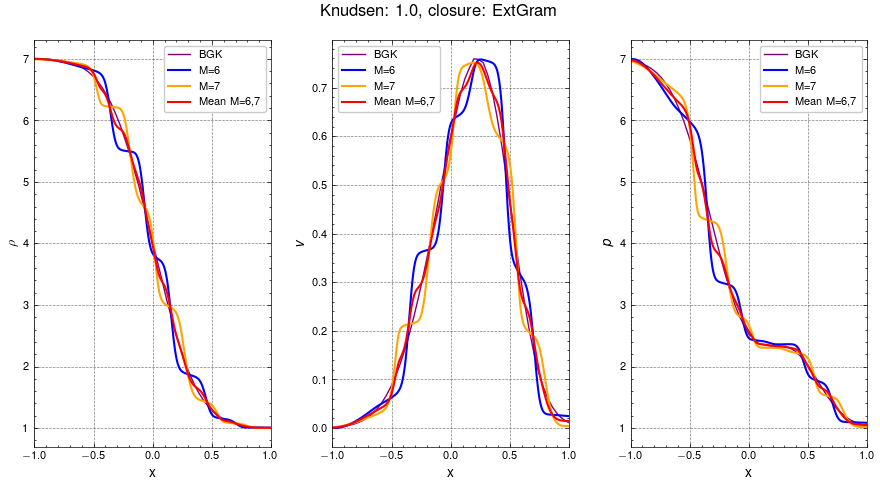

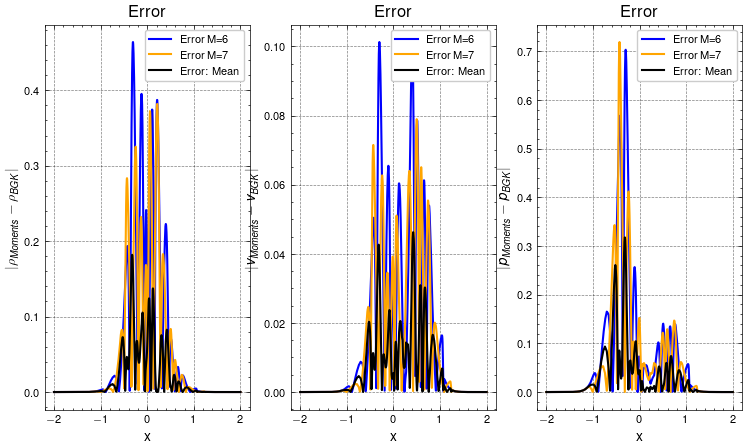

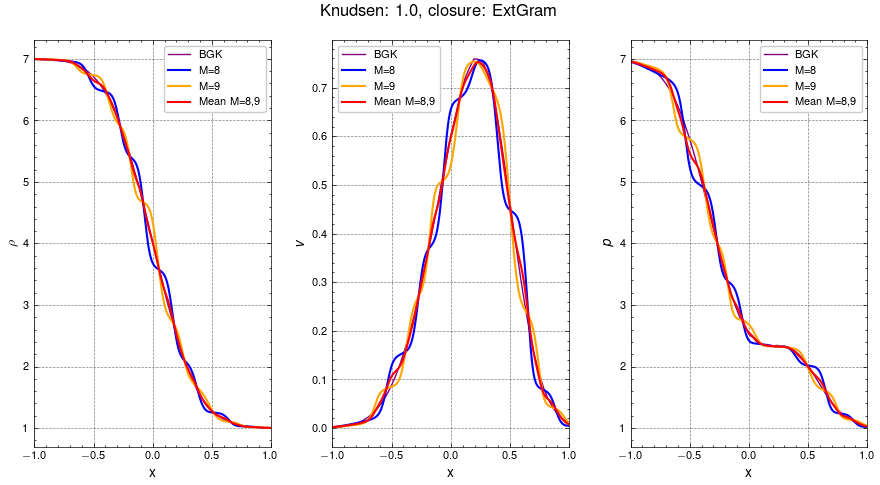

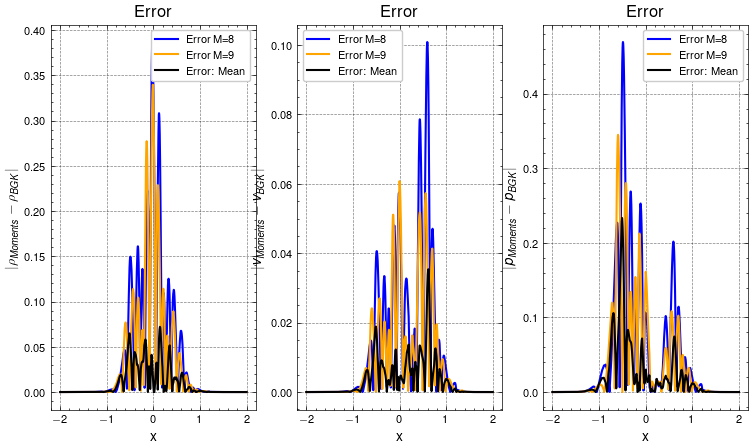

In [49]:
Moments_collected = [[6, 7], [8,9]]
Kn = 1.0
source = "relaxation_source"

for Moments in Moments_collected:
    for closure in closure_vec:
        if closure != "ExtGram":
            continue # only interested in Extended Gramian here
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
        fig_error, axs_error = plt.subplots(1, 3)

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

        # BGK
        if source == "relaxation_source":
            data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

            x_bgk = data_bgk['x'].to_numpy()
            rho_bgk = data_bgk['rho'].to_numpy()
            v_bgk = data_bgk['v'].to_numpy()
            p_bgk = data_bgk['p'].to_numpy()
            theta_bgk = p_bgk / rho_bgk
        else: 
            x_bgk = Nx
            rho_bgk = rho_T
            v_bgk = v_T
            p_bgk = p_T
            ax_rho.plot(Nx, rho_T, color=colors[4])
            ax_v.plot(Nx, v_T, color=colors[4])
            ax_p.plot(Nx, p_T, color=colors[4])

        ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')
        ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')
        ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')

        rho_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, rho_bgk)
        v_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, v_bgk)
        p_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, p_bgk)

        rho_vector, v_vector, p_vector = [], [], []
        
        for i, M in enumerate(Moments):
            if closure == "Grad" and M==5:
                continue # diverged
            # Moments
            file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            rho_vector.append(rho)
            v = u[:, 1] / rho
            v_vector.append(v)
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            p_vector.append(p)
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

            axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        # Mean of M=4 and M=5
        if closure != "Grad":
            rho_mean = 0.5 * (rho_vector[0] + rho_vector[1])
            v_mean = 0.5 * (v_vector[0] + v_vector[1])
            p_mean = 0.5 * (p_vector[0] + p_vector[1])

            ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()

        if closure != "Grad":
            axs_error[0].set_title('Error')
            axs_error[0].set_xlabel('x')
            axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{BGK}|$')
            axs_error[1].set_title('Error')
            axs_error[1].set_xlabel('x')
            axs_error[1].set_ylabel('$|v_{Moments} - v_{BGK}|$')
            axs_error[2].set_title('Error')
            axs_error[2].set_xlabel('x')
            axs_error[2].set_ylabel('$|p_{Moments} - p_{BGK}|$')

            axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

        [ax.legend() for ax in axs_error]

        fig.tight_layout()
        fig.show()

## Convergence for ExtGram

/tmp/ipykernel_1224/3410398301.py:102: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/3410398301.py:112: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_L1.show()
/tmp/ipykernel_1224/3410398301.py:127: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_L2.show()
/tmp/ipykernel_1224/3410398301.py:102: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1224/3410398301.py:112: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_L1.show()
/tmp/ipykernel_1224/341039

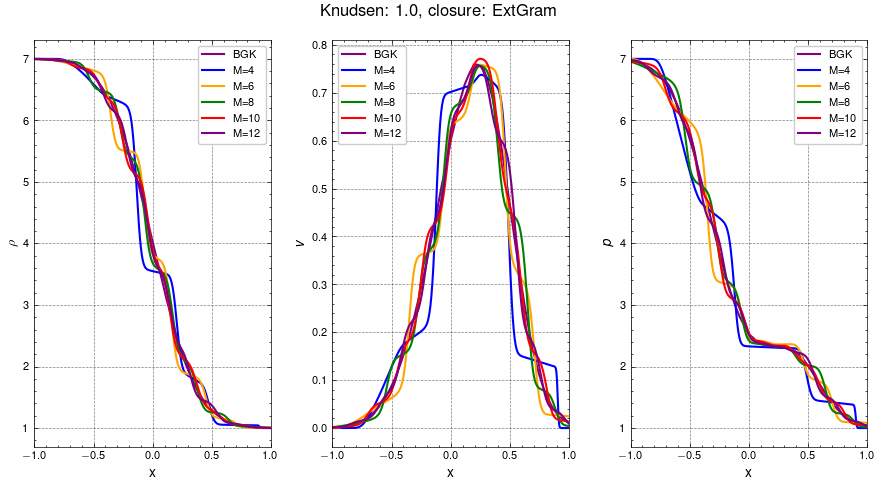

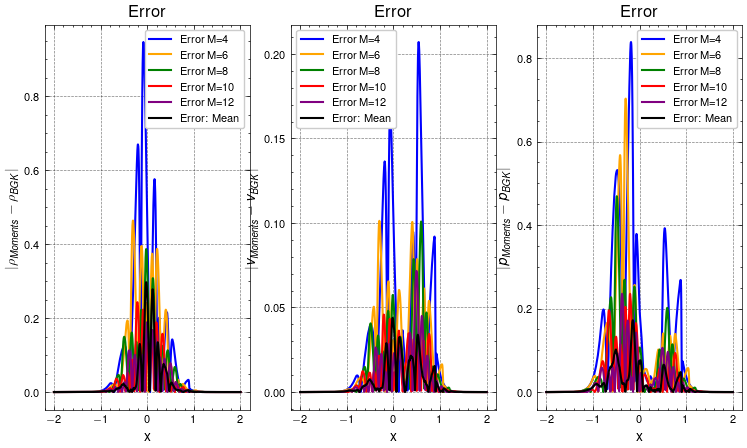

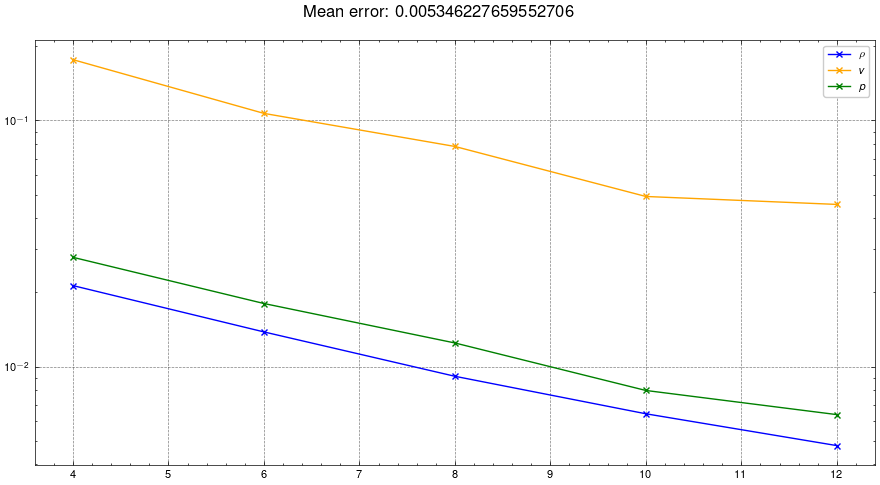

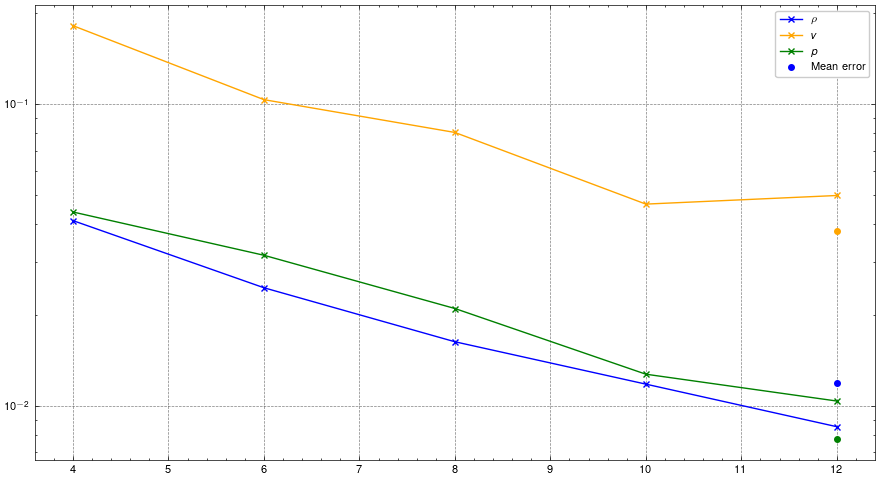

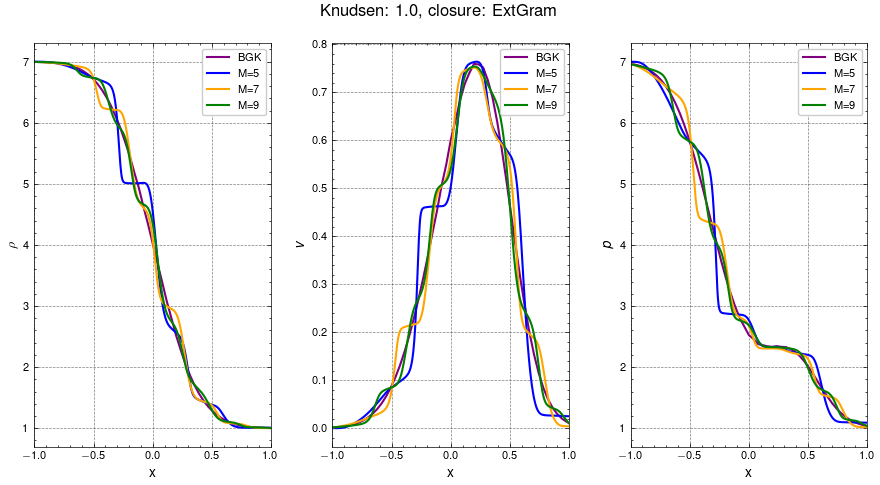

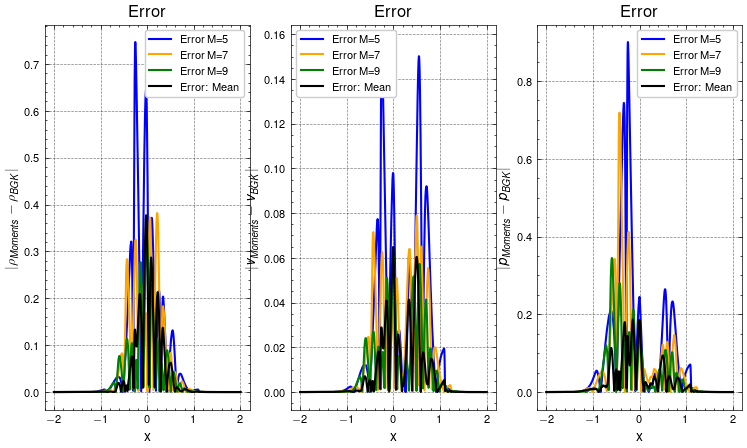

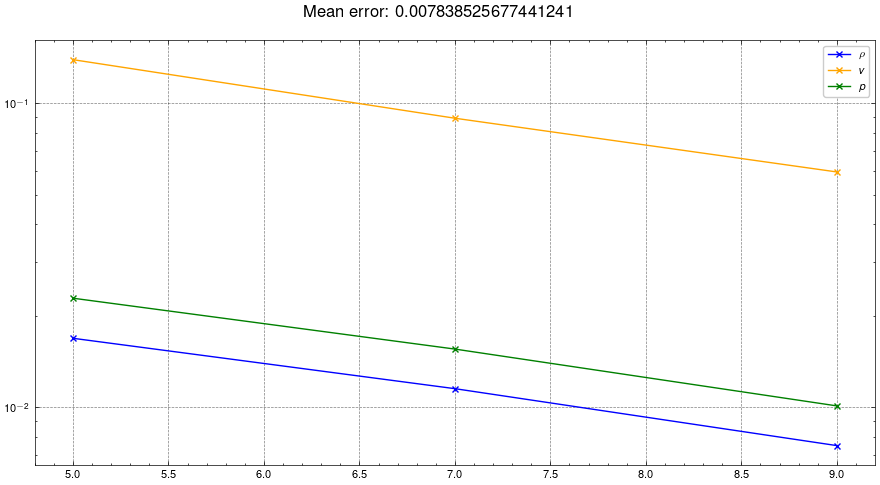

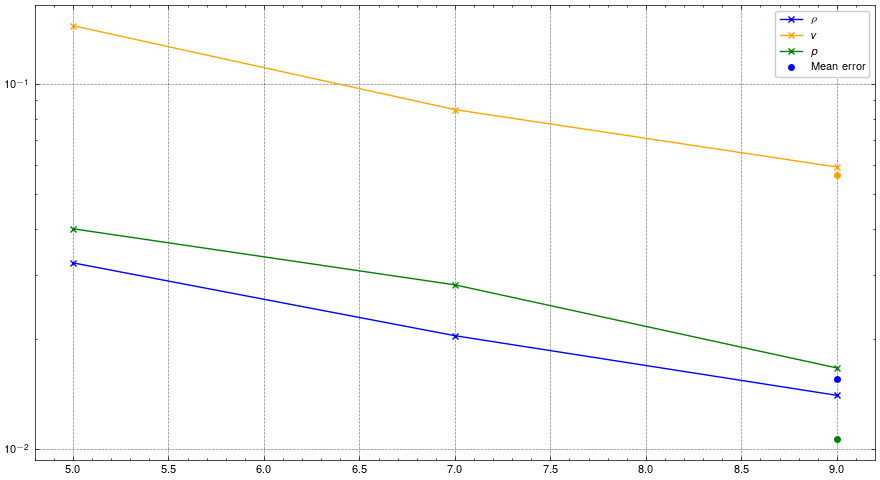

In [50]:
Moments_error_collected = [
    [4, 6, 8, 10, 12],
    [5, 7, 9]
]

Kn = 1.0
closure = "ExtGram"

for Moments_error in Moments_error_collected:
    fig, axs = plt.subplots(1, 3)
    fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
    fig_error, axs_error = plt.subplots(1, 3)

    ax_rho = axs[0]
    ax_v = axs[1]
    ax_p = axs[2]

    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

    # BGK
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

    x_bgk = data_bgk['x'].to_numpy()

    rho_bgk = data_bgk['rho'].to_numpy()
    ax_rho.plot(x_bgk, rho_bgk, color=colors[4], lw=1.5, label='BGK')

    v_bgk = data_bgk['v'].to_numpy()
    ax_v.plot(x_bgk, v_bgk, color=colors[4], lw=1.5, label='BGK')

    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    ax_p.plot(x_bgk, p_bgk, color=colors[4], lw=1.5, label='BGK')

    rho_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, rho_bgk)
    v_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, v_bgk)
    p_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, p_bgk)

    rho_vector, v_vector, p_vector = [], [], []
    rho_L1, v_L1, p_L1 = [], [], []
    rho_L2, v_L2, p_L2 = [], [], []

    for i, M in enumerate(Moments_error):
        # Moments
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        rho_vector.append(rho)
        v = u[:, 1] / rho
        v_vector.append(v)
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        p_vector.append(p)
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

        axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
        axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
        axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        rho_L1.append(np.linalg.norm(rho_bgk_fct(x) - rho, 1) / np.linalg.norm(rho_bgk_fct(x), 1))
        rho_L2.append(np.linalg.norm(rho_bgk_fct(x) - rho, 2) / np.linalg.norm(rho_bgk_fct(x), 2))
        v_L1.append(np.linalg.norm(v_bgk_fct(x) - v, 1) / np.linalg.norm(v_bgk_fct(x), 1))
        v_L2.append(np.linalg.norm(v_bgk_fct(x) - v, 2) / np.linalg.norm(v_bgk_fct(x), 2))
        p_L1.append(np.linalg.norm(p_bgk_fct(x) - p, 1) / np.linalg.norm(p_bgk_fct(x), 1))
        p_L2.append(np.linalg.norm(p_bgk_fct(x) - p, 2) / np.linalg.norm(p_bgk_fct(x), 2))

    rho_mean = np.mean(np.array(rho_vector), axis=0)
    v_mean = np.mean(np.array(v_vector), axis=0)
    p_mean = np.mean(np.array(p_vector), axis=0)

        # ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
        # ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
        # ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label='Mean M=4,5')

    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()

    axs_error[0].set_title('Error')
    axs_error[0].set_xlabel('x')
    axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{BGK}|$')
    axs_error[1].set_title('Error')
    axs_error[1].set_xlabel('x')
    axs_error[1].set_ylabel('$|v_{Moments} - v_{BGK}|$')
    axs_error[2].set_title('Error')
    axs_error[2].set_xlabel('x')
    axs_error[2].set_ylabel('$|p_{Moments} - p_{BGK}|$')

    axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
    axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
    axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

    [ax.legend() for ax in axs_error]

    fig.tight_layout()
    fig.show()

    fig_L1, axs_L1 = plt.subplots()
    fig_L1.suptitle(f'Mean error: {np.linalg.norm(rho_bgk_fct(x) - rho_mean, 1) / np.linalg.norm(rho_bgk_fct(x), 1)}')
    axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[0], label="$\\rho$")
    axs_L1.semilogy(Moments_error, v_L1, '-x', color=colors[1], label='$v$')
    axs_L1.semilogy(Moments_error, p_L1, '-x', color=colors[2], label='$p$')
    axs_L1.legend()

    fig_L1.tight_layout()
    fig_L1.show()



    fig_L2, axs_L2 = plt.subplots()
    # fig_L2.suptitle(f'Mean error: {np.linalg.norm(rho_bgk_fct(x) - rho_mean, 2) / np.linalg.norm(rho_bgk_fct(x), 2)}')
    axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[0], label="$\\rho$")
    axs_L2.semilogy(Moments_error, v_L2, '-x', color=colors[1], label='$v$')
    axs_L2.semilogy(Moments_error, p_L2, '-x', color=colors[2], label='$p$')
    axs_L2.scatter(Moments_error[-1], np.linalg.norm(rho_bgk_fct(x) - rho_mean, 2) / np.linalg.norm(rho_bgk_fct(x), 2), color=colors[0], label='Mean error')
    axs_L2.scatter(Moments_error[-1], np.linalg.norm(v_bgk_fct(x) - v_mean, 2) / np.linalg.norm(v_bgk_fct(x), 2), color=colors[1])
    axs_L2.scatter(Moments_error[-1], np.linalg.norm(p_bgk_fct(x) - p_mean, 2) / np.linalg.norm(p_bgk_fct(x), 2), color=colors[2])
    axs_L2.legend()

    fig_L2.tight_layout()
    fig_L2.show()

## Test-values for analytical

In [93]:
base_tree_level = 10
M = 4
closure = "Gram"

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)
# x_dest = 0.0
# x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
# eigenvalues_at_x = df['eigenvalue'][x_idx]
eigenvalue_string = df['eigenvalue'][0]
eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
eigenvalues_at_x, len(eigenvalues_at_x), type(eigenvalues_at_x)

([-1.7320508075688705,
  -1.0000000000000164,
  7.343512411761791e-18,
  1.000000000000016,
  1.7320508075688683],
 5,
 list)

-------------------------
Closure: Gram
Closure: Gram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208365e-16, 21.00000000000005]
Eigenvalues:  [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]


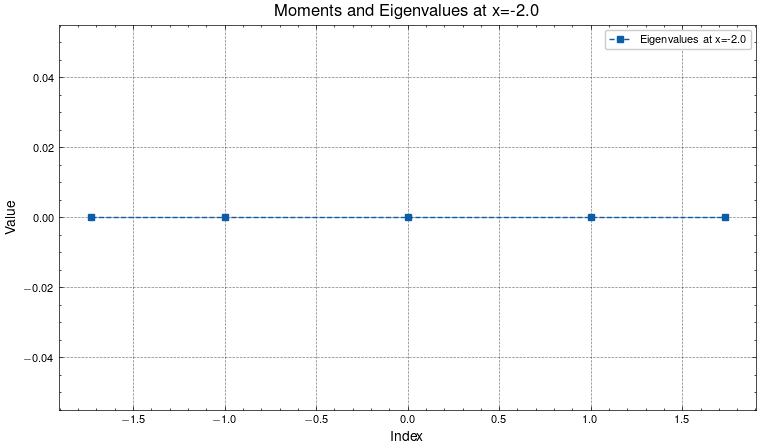

-------------------------
Closure: Gram
Moments:  [4.0650907550333475, 2.0383488637067035, 3.9588654955706986, 5.024542500022368, 11.605619181454587]
Eigenvalues:  [-1.8078602772817343, -0.33263458572158683, 0.10227345381302826, 1.3675954533696728, 1.705588341835701]


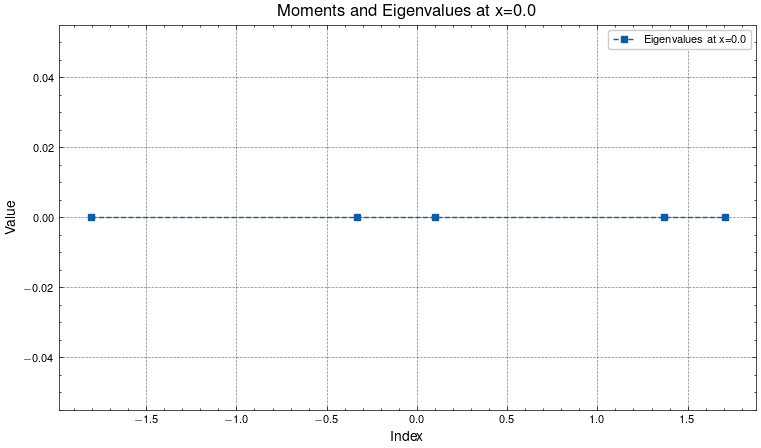

-------------------------
-------------------------
Closure: ExtGram
Closure: ExtGram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208246e-16, 21.00000000000005]
Eigenvalues:  [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]


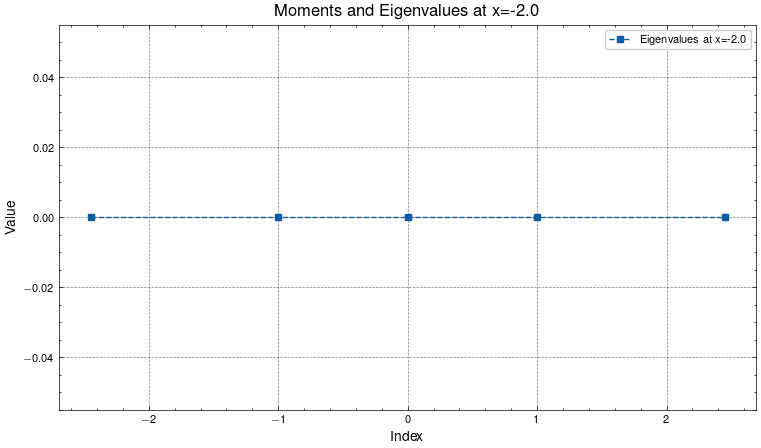

-------------------------
Closure: ExtGram
Moments:  [3.550026843708628, 2.491368531953177, 4.076295856289046, 4.763311397172827, 11.550461451246191]
Eigenvalues:  [-2.2518592611616595, -0.4525403891587826, 0.6708755295229323, 1.269855313553854, 2.8069569592530366]


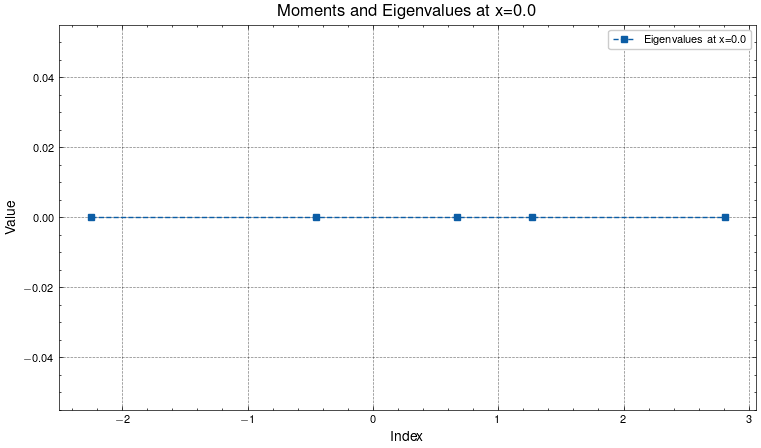

-------------------------
-------------------------
Closure: Grad
Closure: Grad
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208217e-16, 21.00000000000005]
Eigenvalues:  [-2.856970012466309, -1.355626180463204, 3.976422061629331e-11, 1.3556261803745733, 2.8569700133035982]


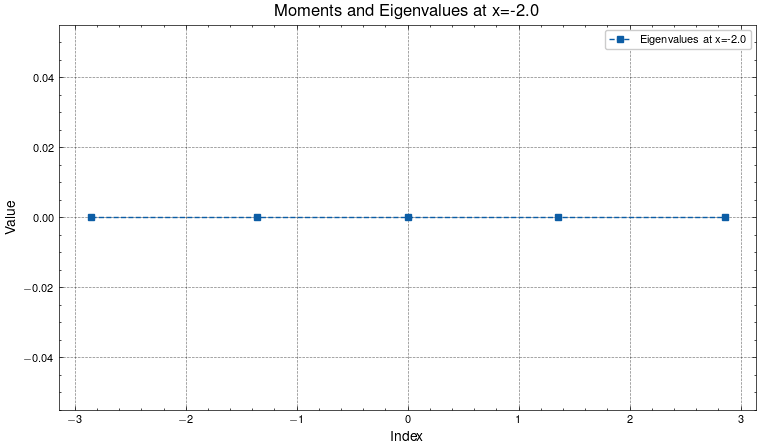

-------------------------
Closure: Grad
Moments:  [3.723783862020578, 2.4343211246770773, 4.037715070733441, 4.682822653085811, 11.658997542910008]
Eigenvalues:  [-2.0411424914864758, -0.06844970514869088, 1.2651717252677173, 1.2651717252677173, 2.8478610353752876]


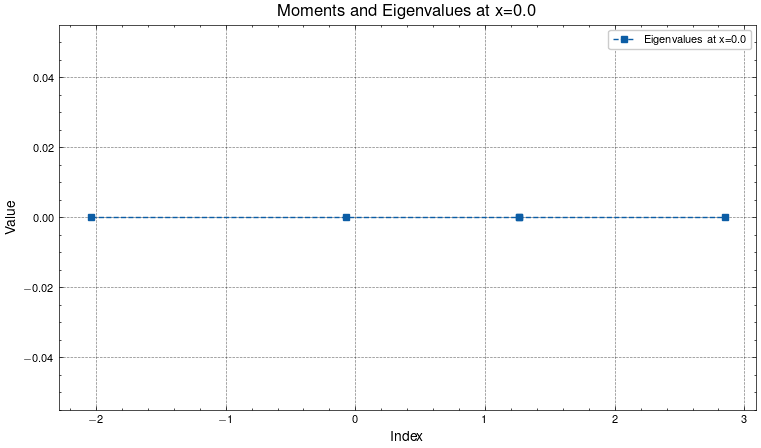

-------------------------


In [94]:
M_vector = [4]
for M in M_vector:
    for closure in closure_vec:
        print("-------------------------")
        print(f'Closure: {closure}')
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)

        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)


        x_dest = -2.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

# Analytical

### M = 4

In [95]:
from sympy import *
u0, u1, u2, u3, u4, u5 = symbols('u0 u1 u2 u3 u4 u5')
c = symbols('c')
init_printing(use_unicode=True)

In [96]:
M = 4
n = int(M/2)

## Gramian

In [97]:
P_Gramian = lambda c: (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
) * (
    c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42
)
P = simplify(P_Gramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P_Gramian)}')
P_Gramian

Latex expression of characteristic polynomial: \mathtt{\text{<function <lambda> at 0x778c99b01f30>}}


<function __main__.<lambda>(c)>

In [98]:
#! We don't want to use this, it seems to add imaginary parts due to numerical errors

# # Roots of P give the eigenvalues of DF
# roots = solve(Eq(P, 0), c)
# roots = [simplify(root) for root in roots]
# print(f'Latex expression of roots: {latex(roots)}')
# roots

In [99]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)

closure = "Gram"
source = "relaxation_source"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [100]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_Gramian_subs = P_Gramian(c).subs(subs_dict_equilibrium)
P_Gramian_subs = simplify(P_Gramian_subs)

roots = solve(Eq(P_Gramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.73205080756888, -1.00000000000000, 0, 1.00000000000000, 1.73205080756888]
Sorted Test Eigenvalues: [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]
Relative Errors: [3.84592537276714e-15, 1.64313007644520e-14, 1.00000000000000, 1.59872115546020e-14, 5.12790049702286e-15]
Absolute Errors: [6.66133814775094e-15, 1.64313007644523e-14, 7.34351241176179e-18, 1.59872115546023e-14, 8.88178419700125e-15]


In [101]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [102]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_Gramian_subs = P_Gramian(c).subs(subs_dict)
P_Gramian_subs = simplify(P_Gramian_subs)

roots = solve(Eq(P_Gramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.80786042693896, -0.332634648413377, 0.102273422508968, 1.36759703781471, 1.70558700442999]
Sorted Test Eigenvalues: [-1.8078602772817343, -0.33263458572158683, 0.10227345381302826, 1.3675954533696728, 1.705588341835701]
Relative Errors: [8.27814092631686e-8, 1.88470450442112e-7, 3.06081968208717e-7, 1.15856266586887e-6, 7.84131598746162e-7]
Absolute Errors: [1.49657221504285e-7, 6.26917902035729e-8, 3.13040600385950e-8, 1.58444503428612e-6, 1.33740571328644e-6]


## Extended Gramian

In [103]:
chi = (n+1) / n

In [104]:
p_nm = lambda c: c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]
p_n = lambda c: c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]
p_np = lambda c: c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42

sigma_nn = Matrix([u4])[0] - Matrix(Matrix([u2, u3]).T * Matrix([[u0, u1],[u1, u2]]).inv() * Matrix([u2, u3]))[0]
sigma_nmnm = u2 - u1 * u1 / u0

In [105]:
P_ExtendedGramian = lambda c: p_n(c) * (p_np(c) - chi * sigma_nn / sigma_nmnm * p_nm(c)) 
P = simplify(P_ExtendedGramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P)}')
P_ExtendedGramian

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(- c^{3} \left(u_{0} u_{2} - u_{1}^{2}\right)^{2} - 1.5 \left(c u_{0} - u_{1}\right) \left(u_{2} \left(- u_{1} u_{3} + u_{2}^{2}\right) + u_{3} \left(u_{0} u_{3} - u_{1} u_{2}\right) - u_{4} \left(u_{0} u_{2} - u_{1}^{2}\right)\right) + \left(u_{0} u_{2} - u_{1}^{2}\right) \left(- u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{3}}


<function __main__.<lambda>(c)>

In [106]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)
closure = "ExtGram"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [107]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict_equilibrium)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict_equilibrium).evalf() for root in roots]

print("Computed Eigenvalues at Equilibrium:", roots_subs)
# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Computed Eigenvalues at Equilibrium: [-2.44948974278318, -1.00000000000000, 0.0, 1.00000000000000, 2.44948974278318]
Sorted Computed Eigenvalues: [-2.44948974278318, -1.00000000000000, 0, 1.00000000000000, 2.44948974278318]
Sorted Test Eigenvalues: [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]
Relative Errors: [5.25766116130737e-15, 1.31006316905767e-14, 1.00000000000000, 1.37667655053518e-14, 4.89506383983789e-15]
Absolute Errors: [1.28785870856518e-14, 1.31006316905768e-14, 7.78350085366586e-18, 1.37667655053519e-14, 1.19904086659517e-14]


In [108]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [109]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)
print(P_ExtendedGramian_subs)

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(roots_subs)
# roots_subs = [root.subs(subs_dict).evalf() for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

-(-c**2 + 0.817315261890856*c + 0.574661100308158)*(c**3 - 6.9504786578284*c + 3.53599929397697)
[-0.452540464522791, 1.26985572641365, -2.86117693829085 - 0.e-22*I, 0.530183808077506 + 0.e-20*I, 2.33099313021335 + 0.e-20*I]
Sorted Computed Eigenvalues: [-2.86117693829085, -0.452540464522791, 0.530183808077506, 1.26985572641365, 2.33099313021335]
Sorted Test Eigenvalues: [-2.2518592611616595, -0.4525403891587826, 0.6708755295229323, 1.269855313553854, 2.8069569592530366]
Relative Errors: [0.270584262364099, 1.66535430269279e-7, 0.209713598505335, 3.25123491324620e-7, 0.169565773878610]
Absolute Errors: [0.609317677129193, 7.53640084227847e-8, 0.140691721445426, 4.12859793019749e-7, 0.475963829039690]


## Visualize eigenvalues in equilibrium

In [110]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

# Gramian
P_Gramian_subs = P_Gramian(c).subs(subs_dict_equilibrium)
P_Gramian_subs = simplify(P_Gramian_subs)

roots_Gramian = solve(Eq(P_Gramian_subs, 0), c)
roots_subs_Gramian = [simplify(root) for root in roots_Gramian]

# Extended Gramian
P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict_equilibrium)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)

roots_ExtendedGramian = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs_ExtendedGramian = [simplify(root) for root in roots_ExtendedGramian]

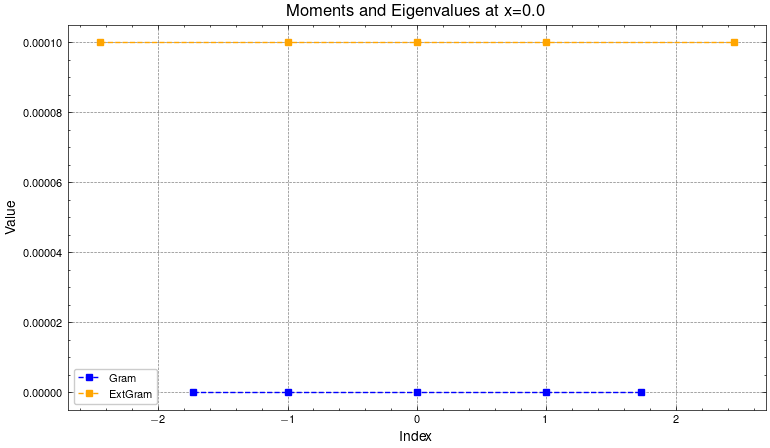

In [111]:
plt.subplots()
plt.plot(roots_subs_Gramian, [0]*len(roots_subs_Gramian), 's--', color='blue', label=f'Gram')
plt.plot(roots_subs_ExtendedGramian, [1e-4]*len(roots_subs_ExtendedGramian), 's--', color='orange', label=f'ExtGram')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title(f'Moments and Eigenvalues at x={x_dest}')
plt.legend()
plt.show()